In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/ecommerce_customer_behavior_dataset_v2.csv")

df.head()



,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,29-05-2023,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,12-10-2023,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,05-12-2023,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,11-05-2023,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,16-06-2023,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [11]:
experience_summary = (
    df.groupby("Delivery_Time_Days")
      .agg(
          avg_rating=("Customer_Rating", "mean"),
          total_orders=("Order_ID", "nunique")
      )
      .reset_index()
      .sort_values("Delivery_Time_Days")
)

experience_summary


,Delivery_Time_Days,avg_rating,total_orders
0,1,3.755365,233
1,2,3.912029,1114
2,3,3.924433,1985
3,4,3.878626,2241
4,5,3.914836,2231
5,6,3.916626,2063
6,7,3.912218,1686
7,8,3.917282,1354
8,9,3.903196,1095
9,10,3.878750,800


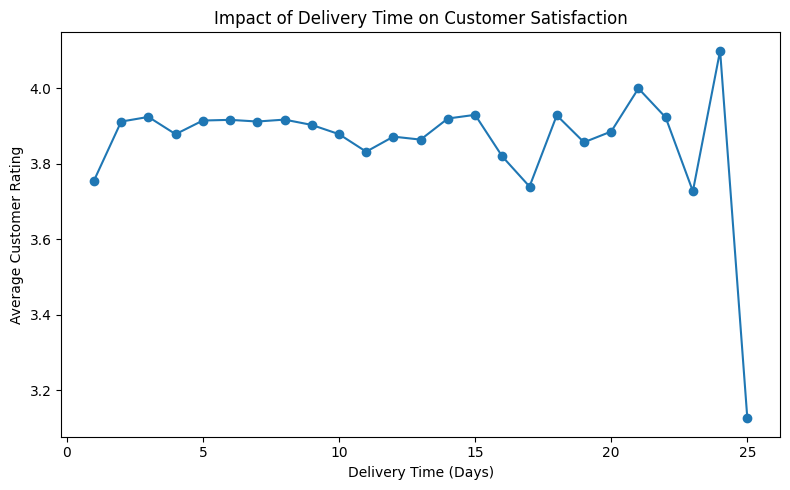

In [12]:
plt.figure(figsize=(8,5))
plt.plot(
    experience_summary["Delivery_Time_Days"],
    experience_summary["avg_rating"],
    marker="o"
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Average Customer Rating")
plt.title("Impact of Delivery Time on Customer Satisfaction")
plt.tight_layout()
plt.show()


### Business Insight
Customer satisfaction remains relatively stable for delivery times up to around 10–12 days, with average ratings close to 3.8–3.9. Beyond this threshold, ratings become more volatile and generally decline, indicating rising customer dissatisfaction as delivery delays increase. Extremely long delivery times are associated with sharp drops in ratings, highlighting delivery speed as a critical driver of customer experience. Reducing long-tail delivery delays can significantly improve overall customer satisfaction and retention.
